# Lipid Membrane GNN — Colab Training

Physics-informed Heterogeneous GNN for membrane property prediction.

## How to use

1. Place `colab_lipid_gnn_subset.zip` (generated by `prepare_colab_subset.py`) in `MyDrive/data/`.
2. Run **Section 0** (environment setup) once per Colab session.
3. Edit **Section 1** (experiment configuration) to define your sweep.
4. Run **Sections 2–4** to load data, define training, and launch runs.

The zip contains preprocessed `.pt` graph chunks and the `lipid_gnn` library.  
No raw trajectory files or MDAnalysis are required at training time.

## Section 0 — Environment Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls "/content"

drive  sample_data


In [4]:
!cp "/content/drive/MyDrive/data/colab_lipid_gnn_subset.zip" .

In [5]:
%%capture
!pip install torch-geometric tqdm scikit-learn matplotlib wandb -q MDAnalysis

In [6]:
# Dynamically build the find-links URL from the live PyTorch/CUDA versions
import torch
TORCH = torch.__version__.split('+')[0]
CUDA  = 'cu' + torch.version.cuda.replace('.', '')
print(f"Installing PyG extensions for PyTorch {TORCH} + {CUDA} ...")
!pip install torch_scatter torch_sparse torch_cluster \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html -q
print("Done.")

Installing PyG extensions for PyTorch 2.10.0 + cu128 ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 125.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 77.1 MB/s eta 0:00:00:00:01
Done.


In [7]:
import os
from pathlib import Path

if not os.path.exists('colab_lipid_gnn_subset.zip'):
    raise FileNotFoundError(
        "colab_lipid_gnn_subset.zip not found. Run the Drive copy cell first."
    )

!unzip -o colab_lipid_gnn_subset.zip -d . > /dev/null 2>&1

chunks = sorted(Path('colab_lipid_gnn_subset/processed').glob('chunk_*.pt'))
if not chunks:
    raise FileNotFoundError(
        "No chunk files found in colab_lipid_gnn_subset/processed/. "
        "Re-generate the zip with prepare_colab_subset.py."
    )
print(f"Extracted successfully — {len(chunks)} chunk files ready.")

Extracted successfully — 70 chunk files ready.


In [8]:
import sys
import random
import itertools
import gc

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from torch_geometric.loader import DataLoader
import wandb

# Expose lipid_gnn without the colab_lipid_gnn_subset prefix
sys.path.insert(0, 'colab_lipid_gnn_subset')

from lipid_gnn.dataset import MartiniDiskDataset
from lipid_gnn.membrane_prop_gnn import MembranePropertyGNN
from lipid_gnn.plotting import plot_property_accuracies
from lipid_gnn.lipid_graph import LIPID_COMP_DIM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")

Device  : cuda
PyTorch : 2.10.0+cu128
CUDA    : 12.8


In [9]:
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pbkushing (pbkushing-ig-farben-haus) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 1 — Experiment Configuration

This is the only cell you need to edit between experiments.

- **`PROPERTIES`** — targets to predict (must match what was baked in by `prepare_colab_subset.py`).
- **`FIXED`** — hyperparameters that are identical across all runs.
- **`SWEEP`** — every combination of these values becomes one W&B run.

The cell prints the full experiment list so you can review it before committing to a long run.

In [10]:
# ── Properties to predict ─────────────────────────────────────────────────────
# Available: 'lipid_packing', 'thickness', 'thickness_std',
#            'compressibility', 'persistence', 'diffusivity'
PROPERTIES = ['lipid_packing', 'thickness']

# ── Fixed hyperparameters (shared across all runs) ────────────────────────────
FIXED = {
    "epochs":      25,
    "batch_size":  8,
    "num_workers": 2,
}

# ── Sweep grid: every combination produces one run ────────────────────────────
# comp_mode: "gnn_only"      — message passing only
#            "gnn_plus_comp" — GNN output + lipid composition vector
#            "comp_only"     — composition vector through MLP only (ablation)
SWEEP = {
    "comp_mode":     ["gnn_only"],
    "hidden_dim":    [32],
    "num_layers":    [2],
    "learning_rate": [5e-4],
    "weight_decay":  [5e-3],
    "seed":          [0],
}

# ── Expand into a flat list of configs ───────────────────────────────────────
keys = list(SWEEP.keys())
experiments = [
    {**FIXED, "properties": PROPERTIES, **dict(zip(keys, vals))}
    for vals in itertools.product(*SWEEP.values())
]

print(f"Generated {len(experiments)} experiments:\n")
for i, cfg in enumerate(experiments):
    vals_str = '  '.join(f"{k}={cfg[k]}" for k in keys)
    print(f"  [{i:>2}]  {vals_str}")

Generated 1 experiments:

  [ 0]  comp_mode=gnn_only  hidden_dim=32  num_layers=2  learning_rate=0.0005  weight_decay=0.005  seed=0


## Section 2 — Data Loading

Chunk files are split at the file level (80/20 train/val). The `StandardScaler` is fit via a fast
label-only pass over training chunks — no full graphs are loaded into RAM at this stage.

In [12]:
PROCESSED_DIR = Path('colab_lipid_gnn_subset/processed')
VAL_SPLIT     = 0.2
SPLIT_SEED    = 42

# ── Split chunk files ─────────────────────────────────────────────────────────
all_chunks = sorted(PROCESSED_DIR.glob('chunk_*.pt'))
random.seed(SPLIT_SEED)
shuffled = list(all_chunks)
random.shuffle(shuffled)

n_val        = max(1, int(len(shuffled) * VAL_SPLIT))
val_chunks   = shuffled[:n_val]
train_chunks = shuffled[n_val:]

print(f"Total chunks : {len(all_chunks)}")
print(f"Train chunks : {len(train_chunks)}")
print(f"Val chunks   : {len(val_chunks)}")

# ── Fit scaler on training labels (y-only pass) ───────────────────────────────
all_train_y = []
for chunk_file in train_chunks:
    graphs = torch.load(chunk_file, weights_only=False)
    all_train_y.extend(g.y for g in graphs)

y_matrix = torch.cat(all_train_y, dim=0).numpy()
scaler   = StandardScaler().fit(y_matrix)

print(f"\nScaler fit on {len(all_train_y)} training graphs.")
print(f"  means : {dict(zip(PROPERTIES, scaler.mean_.round(4)))}")
print(f"  stds  : {dict(zip(PROPERTIES, scaler.scale_.round(4)))}")

# ── Create datasets ───────────────────────────────────────────────────────────
train_dataset = MartiniDiskDataset(train_chunks, shuffle=True)
val_dataset   = MartiniDiskDataset(val_chunks,   shuffle=False)
print("\nDatasets ready.")

Total chunks : 70
Train chunks : 56
Val chunks   : 14

Scaler fit on 2800 training graphs.
  means : {'lipid_packing': np.float64(3.0354), 'thickness': np.float64(38.7269)}
  stds  : {'lipid_packing': np.float64(0.2241), 'thickness': np.float64(1.404)}

Datasets ready.


## Section 3 — Training

In [13]:
def cleanup():
    """Release GPU memory and kill DataLoader worker processes."""
    torch.cuda.empty_cache()
    gc.collect()
    if wandb.run is not None:
        wandb.finish(quiet=True)


def train_one_run(cfg, scaler, train_dataset, val_dataset):
    """Train a single run defined by cfg and log all results to W&B."""
    seed       = cfg["seed"]
    properties = cfg["properties"]
    comp_mode  = cfg["comp_mode"]

    torch.manual_seed(seed)
    np.random.seed(seed)

    use_amp  = device.type == 'cuda'
    # bfloat16 has the same exponent range as float32 — no overflow/NaN in attention.
    # float16 overflows in GATv2Conv attention on random init, producing NaN.
    amp_dtype = torch.bfloat16

    # ── W&B ──────────────────────────────────────────────────────────────────
    run_name = (
        f"{comp_mode}"
        f"_h{cfg['hidden_dim']}"
        f"_l{cfg['num_layers']}"
        f"_lr{cfg['learning_rate']:.0e}"
        f"_s{seed}"
    )
    wandb.init(
        project="lipid_gnn_" + "_".join(properties),
        name=run_name,
        config=cfg,
    )

    # ── DataLoaders ───────────────────────────────────────────────────────────
    _loader_kw = dict(
        batch_size=cfg["batch_size"],
        num_workers=cfg["num_workers"],
        pin_memory=use_amp,
        persistent_workers=(cfg["num_workers"] > 0),
        prefetch_factor=(2 if cfg["num_workers"] > 0 else None),
    )
    train_loader = DataLoader(train_dataset, **_loader_kw)
    val_loader   = DataLoader(val_dataset,   **_loader_kw)

    # ── Model ─────────────────────────────────────────────────────────────────
    use_comp = comp_mode in ("gnn_plus_comp", "comp_only")
    comp_dim = LIPID_COMP_DIM if use_comp else 0

    model = MembranePropertyGNN(
        in_channels=4,
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        out_dim=len(properties),
        comp_dim=comp_dim,
    ).to(device)

    # ── Optimizer & scheduler ─────────────────────────────────────────────────
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    criterion  = torch.nn.MSELoss()
    # GradScaler is not needed for bfloat16 (same exponent range as float32).
    amp_scaler = torch.amp.GradScaler(device=device.type, enabled=False)

    # Scaler tensors for per-batch normalization on device
    s_mean  = torch.tensor(scaler.mean_,  dtype=torch.float, device=device)
    s_scale = torch.tensor(scaler.scale_, dtype=torch.float, device=device)

    def normalize(y):
        return (y - s_mean) / s_scale

    def forward(batch):
        comp_vec       = batch.comp_vec.to(device) if use_comp else None
        edge_attr_dict = batch.edge_attr_dict if hasattr(batch, 'edge_attr_dict') else None
        return model(
            batch.x_dict, batch.edge_index_dict, batch.batch_dict,
            edge_attr_dict, comp_vec=comp_vec,
        )

    try:
        # ── Training loop ─────────────────────────────────────────────────────────
        for epoch in range(1, cfg["epochs"] + 1):
            model.train()
            total_train_loss = 0.0
            prop_train_loss  = torch.zeros(len(properties), device=device)
            n_train          = 0

            for batch_idx, batch in enumerate(train_loader):
                batch  = batch.to(device)
                target = normalize(batch.y)

                optimizer.zero_grad()
                with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                    out  = forward(batch)
                    loss = criterion(out, target)
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                amp_scaler.step(optimizer)
                amp_scaler.update()

                n                = batch.num_graphs
                total_train_loss += loss.item() * n
                prop_train_loss  += (torch.mean((out - target) ** 2, dim=0) * n).detach()
                n_train          += n

                if batch_idx % 10 == 0:
                    wandb.log({"batch/loss": loss.item()})

            avg_train_loss = total_train_loss / n_train
            avg_prop_train = (prop_train_loss / n_train).cpu().numpy()

            # ── Validation ────────────────────────────────────────────────────────
            model.eval()
            total_val_loss = 0.0
            prop_val_loss  = torch.zeros(len(properties), device=device)
            all_preds      = []
            all_targets    = []
            n_val          = 0

            with torch.no_grad():
                for batch in val_loader:
                    batch  = batch.to(device)
                    target = normalize(batch.y)
                    with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                        out  = forward(batch)
                        loss = criterion(out, target)

                    n               = batch.num_graphs
                    total_val_loss += loss.item() * n
                    prop_val_loss  += (torch.mean((out - target) ** 2, dim=0) * n).detach()
                    n_val          += n

                    all_preds.append(out.float().cpu().numpy())
                    all_targets.append(target.detach().cpu().numpy())

            avg_val_loss = total_val_loss / n_val
            avg_prop_val = (prop_val_loss / n_val).cpu().numpy()
            scheduler.step(avg_val_loss)

            all_preds   = np.concatenate(all_preds,   axis=0)
            all_targets = np.concatenate(all_targets, axis=0)
            r2_scores   = r2_score(all_targets, all_preds, multioutput="raw_values")

            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch:03d} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")

            metrics = {
                "epoch":            epoch,
                "train/loss_total": avg_train_loss,
                "val/loss_total":   avg_val_loss,
                "learning_rate":    optimizer.param_groups[0]["lr"],
            }
            for i, prop in enumerate(properties):
                metrics[f"train/loss_{prop}"] = avg_prop_train[i]
                metrics[f"val/loss_{prop}"]   = avg_prop_val[i]
                metrics[f"val/r2_{prop}"]     = float(r2_scores[i])
            wandb.log(metrics)

        # ── Final accuracy plot ───────────────────────────────────────────────────
        final_mse = float(np.mean((all_preds - all_targets) ** 2))
        fig = plot_property_accuracies(all_targets, all_preds, properties, final_mse)
        wandb.log({"val/accuracy_plot": wandb.Image(fig)})
        plt.close(fig)

        wandb.finish()

    finally:
        train_loader._iterator = None
        val_loader._iterator   = None
        del train_loader, val_loader, model, optimizer, scheduler
        torch.cuda.empty_cache()
        gc.collect()


print("train_one_run defined.")

train_one_run defined.


## Section 4 — Run Sweep


────────────────────────────────────────────────────────────
Experiment 1 / 1
────────────────────────────────────────────────────────────


Epoch 001 | Train MSE: 0.9747 | Val MSE: 1.5145
Epoch 010 | Train MSE: 0.8749 | Val MSE: 0.9667
Epoch 020 | Train MSE: 0.8417 | Val MSE: 0.8435


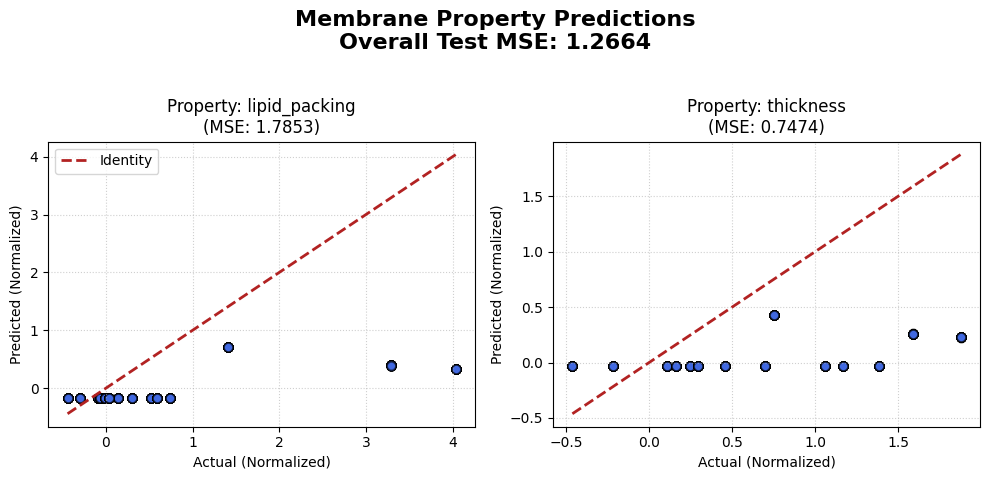

batch/loss,▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▄▂▁▁▁█▂▄▁▁▁▁▁▇▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,█████████████████▁▁▁▁▁▁▁▁
train/loss_lipid_packing,█▅▅▁▅▄▃▁▃▄▂▃▅▄▅▂▃▆▄▃▁▃▅▂▆
train/loss_thickness,█▅▆▃▇▃▄▂▄▆▄▄▅▅▅▁▄▆▅▄▁▃▆▃▆
train/loss_total,█▅▅▁▅▄▃▁▄▅▃▄▅▄▅▁▄▆▄▃▁▃▅▂▆
val/loss_lipid_packing,▇▆▃▇▅▃▁▁▁▃▃▆▂▆▄▅▆▄▅▃▃▁▂█▅
val/loss_thickness,▇█▃█▃▃▁▁▁▃▂▆▂▄▃▄▅▄▅▃▃▂▂▇▅
val/loss_total,▇▇▃█▄▃▁▁▁▃▃▆▂▆▄▅▆▄▅▃▃▂▂█▅
val/r2_lipid_packing,▂▃▆▂▄▆███▆▆▃▇▃▅▄▃▅▄▆▆█▇▁▄
+1,...



All experiments complete.


In [14]:
for i, cfg in enumerate(experiments):
    print(f"\n{'─' * 60}")
    print(f"Experiment {i + 1} / {len(experiments)}")
    print(f"{'─' * 60}")
    cleanup()
    train_one_run(cfg, scaler, train_dataset, val_dataset)

print("\nAll experiments complete.")